In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Kerakli kutubxonalarni yuklash

Ushbu bosqichda sun’iy intellekt modelini yaratish, o‘qitish, sinash va baholash uchun zarur bo‘lgan kutubxonalar yuklandi. Mashinaviy o‘rganish loyihalarida har bir kutubxona ma’lum vazifani bajaradi va model yaratish jarayonining muhim qismi hisoblanadi.

Loyihada ma’lumotlarni boshqarish va tahlil qilish uchun **Pandas** kutubxonasidan foydalanildi. Ushbu kutubxona datasetni yuklash, ustunlar bilan ishlash va ma’lumotlarni qayta ishlash imkonini beradi.

**NumPy** kutubxonasi matematik va statistik hisob-kitoblarni bajarish uchun ishlatildi. U katta hajmdagi sonli ma’lumotlar bilan samarali ishlash imkonini yaratadi.

**Matplotlib** kutubxonasi ma’lumotlar va model natijalarini grafik ko‘rinishda tasvirlash uchun tanlandi. Grafiklar model ishlashini vizual ravishda tahlil qilish imkonini beradi.

Sun’iy intellekt modelini yaratish uchun **Scikit-Learn** kutubxonasidan foydalanildi. Ushbu kutubxona mashinaviy o‘rganish algoritmlarining tayyor va optimallashtirilgan implementatsiyalarini taqdim etadi.

Loyihada quyidagi modellar qo‘llaniladi:

- **Random Forest Classifier** — talabaning grant olish huquqiga ega yoki ega emasligini aniqlash uchun.
- **Random Forest Regressor** — grant olish huquqiga ega talabalar uchun grant foizini bashorat qilish uchun.

Ma’lumotlarni o‘qitish va test to‘plamlariga ajratish uchun **train_test_split** funksiyasi import qilindi. Bu modelning ilgari ko‘rmagan ma’lumotlar ustida qanday ishlashini tekshirish imkonini beradi.

Model samaradorligini baholash uchun bir nechta metrikalar ham yuklandi:

### Classification metrikalari

- **Accuracy Score** — modelning umumiy aniqligini baholaydi.
- **Precision Score** — ijobiy bashoratlarning qanchalik to‘g‘ri ekanligini ko‘rsatadi.
- **Recall Score** — haqiqiy ijobiy natijalarning qanchasi aniqlanganligini ko‘rsatadi.
- **F1 Score** — Precision va Recall ko‘rsatkichlarining muvozanatli bahosini beradi.
- **Confusion Matrix** — modelning to‘g‘ri va noto‘g‘ri bashoratlarini tahlil qilish imkonini beradi.

### Regression metrikalari

- **MAE (Mean Absolute Error)** — bashorat va haqiqiy qiymatlar orasidagi o‘rtacha mutlaq xatolikni hisoblaydi.
- **RMSE (Root Mean Squared Error)** — katta xatoliklarga sezgir bo‘lgan xatolik ko‘rsatkichini hisoblaydi.
- **R² Score** — model ma’lumotlarni qanchalik yaxshi tushuntirib bera olishini ko‘rsatadi.

Natijada sun’iy intellekt modelini yaratish va uning samaradorligini baholash uchun zarur bo‘lgan barcha vositalar muvaffaqiyatli yuklandi.

In [4]:
path = r'../Data/dataset.csv'
df = pd.read_csv(path)

### Datasetni yuklash

Ushbu bosqichda preprocessing jarayonidan o‘tgan va model yaratish uchun tayyorlangan dataset yuklandi.

Dataset tarkibida talabalarning akademik natijalari, davomat ko‘rsatkichlari, motivatsiya darajasi, oilaviy holati hamda grant bilan bog‘liq ma’lumotlar mavjud. Ushbu ma’lumotlar sun’iy intellekt modelini o‘qitish va sinash uchun foydalaniladi.

`pd.read_csv()` funksiyasi yordamida CSV formatdagi fayl DataFrame ko‘rinishida xotiraga yuklandi. DataFrame Pandas kutubxonasining asosiy ma’lumotlar tuzilmasi bo‘lib, ma’lumotlarni jadval shaklida saqlash va ular ustida turli amallar bajarish imkonini beradi.

Datasetni muvaffaqiyatli yuklash model yaratish jarayonining muhim bosqichi hisoblanadi, chunki keyingi barcha amallar aynan ushbu ma’lumotlar asosida bajariladi.

Natijada modelni o‘qitish va baholash uchun zarur bo‘lgan ma’lumotlar ishchi muhitga yuklandi va keyingi bosqichlarga tayyor holatga keltirildi.

In [5]:
x_class = df.drop(
    [
        'Scholarship_Score',
        'Grant_Eligible',
        'Grant_Percent',
        'Grant_Amount'
    ],
    axis=1
)

y_class = df['Grant_Eligible']

### Feature va target ustunlarini ajratish

Sun’iy intellekt modelini o‘qitishdan oldin dataset feature va target qismlarga ajratildi.

Feature sifatida talabaning akademik natijalari, davomat ko‘rsatkichlari, oilaviy holati, motivatsiyasi, o‘qituvchi sifati, internetdan foydalanish imkoniyati va boshqa omillar tanlandi. Ushbu ma’lumotlar grant olish ehtimoliga ta’sir qiluvchi asosiy omillar hisoblanadi.

Target ustuni sifatida `Grant_Eligible` tanlandi. Ushbu ustun model bashorat qilishi kerak bo‘lgan natijani ifodalaydi va talabaning grant olish huquqiga ega yoki ega emasligini ko‘rsatadi.

Quyidagi ustunlar featurelar tarkibidan chiqarib tashlandi:

- **Grant_Eligible** — model bashorat qilishi kerak bo‘lgan target ustun.
- **Grant_Percent** — grant natijasi asosida yaratilgan ustun.
- **Grant_Amount** — grant foizidan hisoblangan yakuniy qiymat.
- **Scholarship_Score** — grant berish jarayonida ishlatilgan va Grant_Eligible ustunini yaratishda foydalanilgan hosila (derived) ustun.

Agar ushbu ustunlar feature sifatida qoldirilsa, model grant natijalari bilan bog‘liq ma’lumotlarni oldindan ko‘rib qoladi. Bu holat **Data Leakage** deb ataladi va modelning sun’iy ravishda juda yuqori aniqlik ko‘rsatishiga olib keladi.

Shu sababli model faqat talaba haqidagi dastlabki ma’lumotlardan foydalanib grant olish ehtimolini aniqlashga o‘rgatiladi. Bu esa modelning haqiqiy sharoitdagi ishlashini aniqroq baholash imkonini beradi.

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

### Ma’lumotlarni o‘qitish va test to‘plamlariga ajratish

Sun’iy intellekt modelining haqiqiy sharoitlarda qanday ishlashini baholash uchun dataset o‘qitish (training) va test (testing) to‘plamlariga ajratildi.

Datasetning 80 foizi modelni o‘qitish uchun, 20 foizi esa modelni sinash uchun ajratildi. O‘qitish to‘plami modelga ma’lumotlar orasidagi bog‘liqliklarni o‘rganish imkonini beradi, test to‘plami esa model ilgari ko‘rmagan ma’lumotlar ustida qanchalik yaxshi ishlashini tekshirish uchun ishlatiladi.

`random_state=42` parametri natijalarning takrorlanuvchanligini ta’minlash uchun qo‘llanildi. Bu kod har safar ishga tushirilganda bir xil train va test to‘plamlari hosil bo‘lishini kafolatlaydi.

`stratify=y_class` parametri esa grant oladigan va grant olmaydigan talabalar nisbatini train va test to‘plamlarida saqlab qolish uchun ishlatildi. Bu modelni yanada adolatli va ishonchli baholash imkonini beradi.

Natijada modelni o‘qitish va sinash uchun alohida ma’lumotlar to‘plamlari yaratildi va keyingi bosqichda Random Forest Classifier modelini o‘qitishga tayyorlandi.

In [7]:
classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

classifier.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Random Forest Classifier modelini yaratish va o‘qitish

Ushbu bosqichda Random Forest Classifier modeli yaratildi va o‘qitish to‘plami yordamida o‘qitildi.

Random Forest algoritmi bir nechta Decision Tree modellaridan tashkil topgan bo‘lib, yakuniy qarorni barcha daraxtlarning umumiy natijasi asosida qabul qiladi. Ushbu yondashuv modelning aniqligini oshiradi va overfitting muammosini kamaytiradi.

Modelni yanada barqaror ishlashi uchun bir nechta parametrlar belgilandi. `n_estimators=200` parametri 200 ta qaror daraxti yaratishni bildiradi. Ko‘proq daraxtlar modelning ishonchliligini oshirishga yordam beradi.

`max_depth=10` parametri daraxtlarning maksimal chuqurligini cheklaydi. Bu modelning o‘qitish ma’lumotlariga haddan tashqari moslashib qolishining oldini oladi.

`min_samples_split=5` parametri esa yangi bo‘linish hosil qilish uchun kamida 5 ta namunani talab qiladi. Bu ham modelning umumlashtirish qobiliyatini yaxshilashga yordam beradi.

Shundan so‘ng `fit()` funksiyasi yordamida model o‘qitish ma’lumotlari asosida o‘qitildi. Natijada model talabalarning ma’lumotlari va grant olish natijalari o‘rtasidagi bog‘liqliklarni o‘rganib oldi va yangi talabalar uchun grant olish ehtimolini bashorat qilishga tayyor holatga keltirildi.

In [8]:
y_pred = classifier.predict(x_test)

### Model yordamida bashorat qilish

Random Forest Classifier modeli muvaffaqiyatli o‘qitilgandan so‘ng, uning samaradorligini baholash uchun test to‘plamidagi ma’lumotlar asosida bashoratlar amalga oshirildi.

`predict()` funksiyasi yordamida model ilgari ko‘rmagan talabalar ma’lumotlarini tahlil qilib, ularning grant olish huquqiga ega yoki ega emasligini aniqladi.

Hosil bo‘lgan natijalar `y_pred` o‘zgaruvchisida saqlandi. Ushbu natijalar keyingi bosqichlarda haqiqiy qiymatlar (`y_test`) bilan taqqoslanadi va modelning qanchalik aniq ishlayotganligi baholanadi.

Bundan tashqari, modelning bashoratlari va haqiqiy natijalari yonma-yon ko‘rsatildi. Bu model qaysi talabalar uchun to‘g‘ri yoki noto‘g‘ri qaror qabul qilganligini aniqlash imkonini beradi.

Mazkur bosqich sun’iy intellekt modelining real ma’lumotlar ustida qanday ishlashini tekshirish va keyingi baholash jarayonlari uchun asos yaratadi.

In [9]:
comparison = pd.DataFrame({
    'Real': y_test,
    'Predicted': y_pred
})

comparison.head(20)

,Real,Predicted
6463,1,1
263,0,0
2579,0,0
5333,1,1
4725,0,0
2098,0,0
697,1,1
1711,1,1
4047,1,1
1887,1,1


### Haqiqiy va bashorat qilingan natijalarni taqqoslash

Modelning ishlashini yanada yaxshiroq tushunish uchun haqiqiy natijalar (`Real`) va model tomonidan bashorat qilingan natijalar (`Predicted`) yonma-yon taqqoslandi.

Ushbu jadval yordamida model qaysi talabalar uchun to‘g‘ri qaror qabul qilganligi va qaysi holatlarda xatoga yo‘l qo‘yganligini ko‘rish mumkin.

`Real` ustuni datasetdagi haqiqiy grant natijasini ifodalaydi, `Predicted` ustuni esa Random Forest Classifier modeli tomonidan bashorat qilingan natijani ko‘rsatadi.

Agar ikkala ustundagi qiymatlar bir xil bo‘lsa, model to‘g‘ri bashorat qilgan hisoblanadi. Agar qiymatlar farq qilsa, model ushbu talaba uchun noto‘g‘ri qaror qabul qilgan bo‘ladi.

Mazkur taqqoslash modelning real ma’lumotlar ustida qanday ishlayotganligini vizual ravishda tahlil qilish va keyingi baholash bosqichlari uchun muhim ma’lumotlarni taqdim etadi.

In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9418
Precision: 0.9402
Recall   : 0.9720
F1 Score : 0.9559


### Classification modelining samaradorligini baholash

Model o‘qitilgandan so‘ng uning samaradorligi bir nechta baholash metrikalari yordamida tahlil qilindi.

Natijalar quyidagicha bo‘ldi:

- Accuracy: 94.18%
- Precision: 94.02%
- Recall: 97.20%
- F1 Score: 95.59%

Accuracy natijasi model test ma’lumotlarining 94.18 foizida to‘g‘ri bashorat berganligini ko‘rsatadi. Bu model grant olish huquqini aniqlashda yuqori aniqlikka ega ekanligini bildiradi.

Precision ko‘rsatkichi 94.02 foizni tashkil etdi. Bu model grant beriladi deb bashorat qilgan talabalar orasida 94 foizdan ortig‘i haqiqatan ham grant olish huquqiga ega ekanligini anglatadi.

Recall natijasi 97.20 foiz bo‘ldi. Ushbu ko‘rsatkich grant olish huquqiga ega talabalarning juda katta qismi model tomonidan muvaffaqiyatli aniqlanganligini ko‘rsatadi.

F1 Score qiymati 95.59 foizni tashkil etdi. Bu Precision va Recall ko‘rsatkichlari o‘rtasida yaxshi muvozanat mavjudligini va modelning umumiy ishlashi yuqori darajada ekanligini bildiradi.

Olingan natijalar Random Forest Classifier modelining grant olish huquqini aniqlash vazifasini muvaffaqiyatli bajarayotganligini ko‘rsatadi.

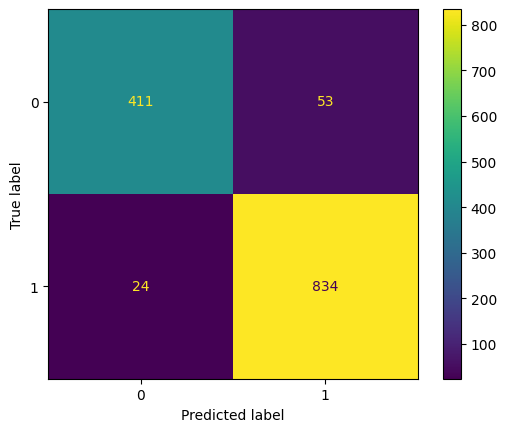

In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

### Confusion Matrix yordamida model natijalarini tahlil qilish

Model samaradorligini yanada chuqurroq tahlil qilish uchun Confusion Matrix qurildi. Ushbu matritsa modelning qaysi holatlarda to‘g‘ri va qaysi holatlarda noto‘g‘ri bashorat qilganligini ko‘rsatadi.

Natijalarga ko‘ra:

- 411 ta holatda model grant berilmasligi kerak bo‘lgan talabalarni to‘g‘ri aniqlagan.
- 834 ta holatda model grant berilishi kerak bo‘lgan talabalarni to‘g‘ri aniqlagan.
- 53 ta holatda model grant berilmasligi kerak bo‘lgan talabalarga grant beriladi deb noto‘g‘ri bashorat qilgan.
- 24 ta holatda esa grant berilishi kerak bo‘lgan talabalarni grant olmaydi deb noto‘g‘ri baholagan.

Confusion Matrix natijalari modelning aksariyat hollarda to‘g‘ri qaror qabul qilayotganligini ko‘rsatadi. Ayniqsa grant olish huquqiga ega talabalarni aniqlashdagi xatolar soni juda kam bo‘lib, bu Recall ko‘rsatkichining yuqori chiqishiga sabab bo‘lgan.

Mazkur natijalar Accuracy (94.18%), Precision (94.02%), Recall (97.20%) va F1 Score (95.59%) qiymatlarini tasdiqlaydi hamda Random Forest Classifier modelining grant olish huquqini aniqlash vazifasida samarali ishlayotganligini ko‘rsatadi.

Shunday qilib, Confusion Matrix model samaradorligini vizual ravishda baholash va modelning kuchli hamda zaif tomonlarini aniqlash imkonini berdi.

In [12]:
grant_students = df[df['Grant_Eligible'] == 1]

### Grant olish huquqiga ega talabalarni ajratish

Loyihaning ikkinchi bosqichida grant foizini bashorat qiluvchi regression modeli yaratildi. Ushbu model faqat grant olish huquqiga ega talabalar uchun ishlashi kerak.

Shu sababli datasetdan `Grant_Eligible = 1` bo‘lgan talabalar ajratib olindi. Bu talabalar birinchi bosqichdagi classification modeli tomonidan grant olish huquqiga ega deb topilgan talabalardir.

Bunday yondashuv loyiha arxitekturasiga mos keladi, chunki grant foizini hisoblash faqat grant olish huquqiga ega talabalar uchun ma’noga ega. Grant olish huquqiga ega bo‘lmagan talabalar uchun grant foizi har doim 0 bo‘ladi.

Natijada regression modelini o‘qitish uchun faqat grant oluvchi talabalar ma’lumotlaridan iborat yangi dataset hosil qilindi.

In [13]:
x_reg = grant_students.drop(
    [
        'Scholarship_Score',
        'Grant_Eligible',
        'Grant_Percent',
        'Grant_Amount'
    ],
    axis=1
)

y_reg = grant_students['Grant_Percent']

### Regression modeli uchun feature va target ustunlarini ajratish

Regression modelining maqsadi grant olish huquqiga ega talabalar uchun grant foizini bashorat qilishdan iborat.

Target ustuni sifatida `Grant_Percent` tanlandi. Ushbu ustun model bashorat qilishi kerak bo‘lgan natijani ifodalaydi.

Feature sifatida talabaning o‘qish natijalari, davomat ko‘rsatkichlari, motivatsiya darajasi, oilaviy holati va boshqa omillar tanlandi.

`Grant_Percent`, `Grant_Amount`, `Grant_Eligible` va `Scholarship_Score` ustunlari featurelar tarkibidan chiqarib tashlandi. Ushbu ustunlar grant natijalari bilan bevosita bog‘liq bo‘lgani sababli ularni modelga kiritish Data Leakage muammosiga olib kelishi mumkin.

Natijada model grant foizini faqat talabaning dastlabki ma’lumotlari asosida bashorat qilishga o‘rgatiladi.

In [14]:
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(
    x_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

### Regression modeli uchun ma’lumotlarni o‘qitish va test to‘plamlariga ajratish

Modelning haqiqiy sharoitlarda qanday ishlashini baholash uchun ma’lumotlar o‘qitish va test to‘plamlariga ajratildi.

Datasetning 80 foizi modelni o‘qitish uchun, 20 foizi esa modelni sinash uchun ajratildi.

O‘qitish to‘plami modelga grant foiziga ta’sir qiluvchi omillarni o‘rganish imkonini beradi. Test to‘plami esa modelning ilgari ko‘rmagan ma’lumotlar ustida qanchalik yaxshi ishlashini tekshirish uchun ishlatiladi.

`random_state=42` parametri natijalarning takrorlanuvchanligini ta’minlaydi va eksperimentlarni qayta tiklash imkonini beradi.

Natijada regression modelini o‘qitish va baholash uchun alohida ma’lumotlar to‘plamlari yaratildi.

In [15]:
regressor = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

regressor.fit(x_train_reg, y_train_reg)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Random Forest Regressor modelini yaratish va o‘qitish

Grant tizimining ikkinchi bosqichida Random Forest Regressor modeli yaratildi.

Ushbu modelning vazifasi grant olish huquqiga ega talabalar uchun grant foizini bashorat qilishdan iborat.

Random Forest Regressor bir nechta qaror daraxtlaridan tashkil topgan bo‘lib, yakuniy natijani barcha daraxtlar bashoratlarining o‘rtacha qiymati asosida hisoblaydi. Ushbu yondashuv modelning aniqligini oshirish va xatoliklarni kamaytirishga yordam beradi.

Model parametrlarini optimallashtirish maqsadida 200 ta qaror daraxtidan foydalanildi. Daraxtlarning maksimal chuqurligi 10 daraja bilan cheklab qo‘yildi va yangi bo‘linish hosil qilish uchun kamida 5 ta namuna talab qilindi.

Shundan so‘ng model `fit()` funksiyasi yordamida o‘qitish ma’lumotlari asosida o‘qitildi va grant foizini bashorat qilish uchun tayyor holatga keltirildi.

In [16]:
y_pred_reg = regressor.predict(x_test_reg)

### Grant foizlarini bashorat qilish

Random Forest Regressor modeli muvaffaqiyatli o‘qitilgandan so‘ng test to‘plamidagi ma’lumotlar asosida grant foizlari bashorat qilindi.

`predict()` funksiyasi yordamida model ilgari ko‘rmagan talabalar ma’lumotlarini tahlil qilib, ular uchun grant foizini hisoblab berdi.

Hosil bo‘lgan bashoratlar `y_pred_reg` o‘zgaruvchisida saqlandi. Ushbu natijalar keyingi bosqichlarda haqiqiy grant foizlari bilan taqqoslanadi va modelning qanchalik aniq ishlayotganligi baholanadi.

Mazkur bosqich regression modelining amaliy natijalarini olish va keyingi baholash jarayonlari uchun asos yaratadi.

In [17]:
comparison_reg = pd.DataFrame({
    'Real_Grant_Percent': y_test_reg,
    'Predicted_Grant_Percent': y_pred_reg
})

comparison_reg.head(20)

,Real_Grant_Percent,Predicted_Grant_Percent
5769,75,75.632067
453,85,85.022155
5516,80,80.912281
3914,85,83.161801
3173,75,75.906478
284,80,80.323562
1536,75,75.446541
711,80,79.211254
2918,85,85.105037
3967,80,78.356569


### Haqiqiy va bashorat qilingan grant foizlarini taqqoslash

Regression modelining ishlash sifatini baholash uchun haqiqiy grant foizlari va model tomonidan bashorat qilingan grant foizlari yonma-yon taqqoslandi.

Jadvaldagi haqiqiy qiymatlar va bashorat qilingan qiymatlar o‘rtasidagi farq modelning qanchalik aniq ishlayotganligini ko‘rsatadi.

Agar bashorat qilingan qiymatlar haqiqiy qiymatlarga yaqin bo‘lsa, model grant foizlarini muvaffaqiyatli hisoblay olgan hisoblanadi.

Mazkur taqqoslash modelning real ma’lumotlar ustida qanday ishlayotganligini vizual ravishda tahlil qilish imkonini beradi va keyingi baholash metrikalari uchun asos yaratadi.

In [18]:
mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_reg
    )
)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.0991
RMSE : 1.5697
R²   : 0.8963


### Regression modelining samaradorligini baholash

Grant foizlarini bashorat qiluvchi modelning ishlash sifati MAE, RMSE va R² metrikalari yordamida baholandi.

Natijalar quyidagicha bo‘ldi:

- MAE: 1.0991
- RMSE: 1.5697
- R²: 0.8963

MAE (Mean Absolute Error) qiymati 1.0991 ni tashkil etdi. Bu model bashorat qilgan grant foizlari haqiqiy grant foizlaridan o‘rtacha 1.1 foizga farq qilishini bildiradi. Ushbu natija modelning yuqori aniqlik bilan ishlayotganligini ko‘rsatadi.

RMSE (Root Mean Squared Error) qiymati 1.5697 bo‘ldi. Bu ko‘rsatkich katta xatoliklarni hisobga olgan holda modelning umumiy xatoligini baholaydi. Olingan natija model bashoratlarining haqiqiy qiymatlarga juda yaqin ekanligini ko‘rsatadi.

R² Score qiymati 0.8963 ni tashkil etdi. Bu model grant foizlaridagi o‘zgarishlarning taxminan 89.63 foizini tushuntirib bera olishini bildiradi. R² qiymatining 1 ga yaqin bo‘lishi modelning ma’lumotlar orasidagi bog‘liqliklarni muvaffaqiyatli o‘rganganligini ko‘rsatadi.

Haqiqiy va bashorat qilingan grant foizlarini taqqoslash natijasida model ko‘pchilik holatlarda haqiqiy qiymatlarga juda yaqin natijalar qaytarayotganligi kuzatildi.

Natijalar Random Forest Regressor modelining grant foizlarini bashorat qilish vazifasini muvaffaqiyatli bajarayotganligini ko‘rsatadi.

In [19]:
import joblib

joblib.dump(classifier, '../Models/classifier.pkl')
joblib.dump(regressor, '../Models/regressor.pkl')

['../Models/regressor.pkl']